# Ejemplo de carga y análisis de imagen

In [1]:
import cv2
import matplotlib.pyplot as plt

I = cv2.imread('data/imagen.png')
print(I.shape)


(251, 201, 3)


In [2]:
import numpy as np

In [3]:
# Irgb = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
Ib = I[:, :, 0]
Ig = I[:, :, 1]
Ir = I[:, :, 2]

Irgb = np.stack((Ir, Ig, Ib), axis=2)


(-0.5, 200.5, 250.5, -0.5)

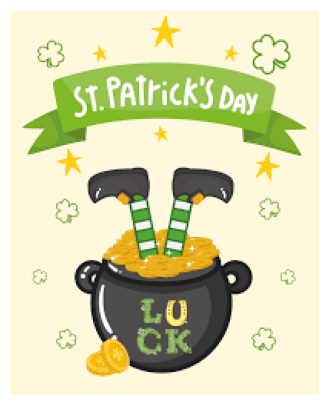

In [4]:
plt.figure(figsize=(5, 5))
plt.imshow(Irgb)
plt.axis('off')

(-0.5, 200.5, 250.5, -0.5)

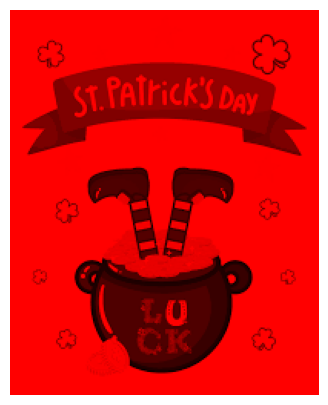

In [5]:
nr, nc, _ = Irgb.shape
Iz = np.zeros((nr, nc), dtype=np.uint8)

Ironly = np.stack((Ir, Iz, Iz), axis=2)

plt.figure(figsize=(5, 5))
plt.imshow(Ironly)
plt.axis('off')

(-0.5, 200.5, 250.5, -0.5)

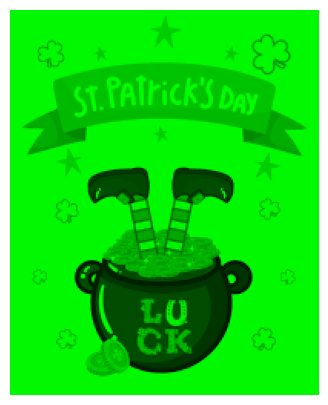

In [6]:
Igonly = np.stack((Iz, Ig, Iz), axis=2)
plt.figure(figsize=(5, 5))
plt.imshow(Igonly)
plt.axis('off')

(-0.5, 200.5, 250.5, -0.5)

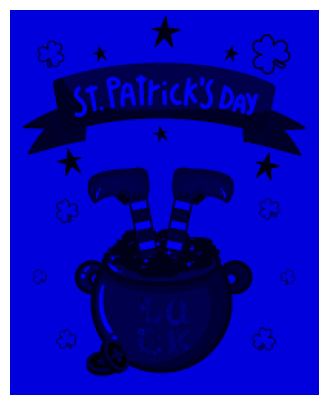

In [7]:
Ibonly = np.stack((Iz, Iz, Ib), axis=2)
plt.figure(figsize=(5, 5))
plt.imshow(Ibonly)
plt.axis('off')

Text(0.5, 1.0, 'Histogram of Red Channel')

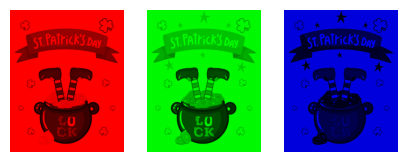

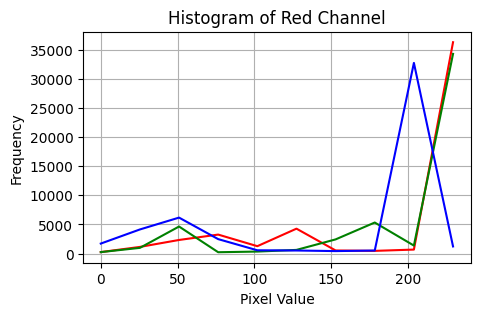

In [8]:
plt.figure(figsize=(5, 10))
plt.subplot(1, 3, 1)
plt.imshow(Ironly)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Igonly)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Ibonly)
plt.axis('off')

h_r, bins_edges_r = np.histogram(Ir.flatten(), bins=10, range=(0, 255))
h_g, bins_edges_g = np.histogram(Ig.flatten(), bins=10, range=(0, 255))
h_b, bins_edges_b = np.histogram(Ib.flatten(), bins=10, range=(0, 255))
plt.figure(figsize=(5, 3))
plt.plot(bins_edges_r[:-1], h_r, color='red')
plt.plot(bins_edges_g[:-1], h_g, color='green')
plt.plot(bins_edges_b[:-1], h_b, color='blue')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid()
plt.title('Histogram of Red Channel')

In [9]:
np.unique(Ib)

array([  0,  14,  16,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  33,  34,  36,  37,  38,  39,  41,  43,  45,  47,
        48,  49,  51,  52,  53,  54,  55,  56,  59,  60,  61,  64,  65,
        66,  67,  70,  71,  72,  73,  76,  77,  78,  79,  82,  85,  86,
        87,  89,  90,  92,  93,  95,  96,  97, 101, 102, 105, 107, 108,
       112, 113, 116, 119, 120, 123, 124, 128, 129, 132, 133, 135, 137,
       138, 139, 142, 143, 145, 149, 154, 156, 158, 160, 164, 165, 166,
       167, 171, 178, 180, 182, 184, 188, 192, 194, 196, 199, 200, 201,
       206, 207, 217, 218, 220, 223, 225, 227, 228, 230, 232, 233, 239,
       244, 255], dtype=uint8)

(-0.5, 200.5, 250.5, -0.5)

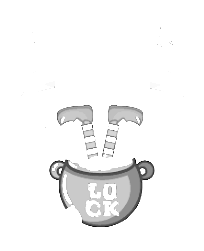

In [10]:
plt.figure(figsize=(5, 3))
plt.imshow(Ir, cmap='gray',vmin=0, vmax=100)
plt.axis('off')

In [11]:
def SaturaEscalav1(A, vmin, vmax):
    ndim = A.ndim
    if ndim == 2:
        nr, nc = A.shape
        Ag = A.copy()
        for ii in range(nr):
            for jj in range(nc):
                if Ag[ii,jj]<vmin:
                    Ag[ii,jj] = vmin
                elif Ag[ii,jj]>vmax:
                    Ag[ii,jj] = vmax
    elif ndim == 3:
        nr, nc, nch = A.shape
        Ag = A.copy()
        for ii in range(nr):
            for jj in range(nc):
                for kk in range(nch):
                    if Ag[ii,jj,kk]<vmin:
                        Ag[ii,jj,kk] = vmin
                    elif Ag[ii,jj,kk]>vmax:
                        Ag[ii,jj,kk] = vmax

    return Ag

def SaturaEscalav2(A, vmin, vmax):
    Ag = A.copy()
    Ag[Ag<vmin] = vmin
    Ag[Ag>vmax] = vmax
    return Ag

Ir_sat = SaturaEscalav1(Ir, 100, 150)
print(np.unique(Ir))
print(np.unique(Ir_sat))



[  0  15  18  25  26  27  31  34  38  40  41  43  44  49  54  55  56  60
  61  62  63  64  65  66  70  71  75  77  78  79  80  81  82  84  88  89
  93  95  97  98 104 107 108 113 114 115 118 122 125 126 127 128 134 136
 137 140 141 142 143 144 145 146 147 148 149 150 151 155 156 157 162 163
 164 167 168 171 173 174 176 182 184 185 186 187 189 191 195 196 199 200
 201 204 208 209 211 212 214 215 216 217 218 219 220 227 228 230 231 232
 233 234 235 236 237 238 240 242 243 244 245 249 250 252 253 254 255]
[100 104 107 108 113 114 115 118 122 125 126 127 128 134 136 137 140 141
 142 143 144 145 146 147 148 149 150]


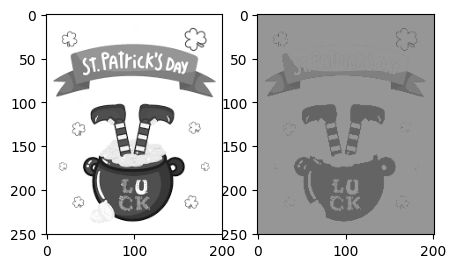

In [12]:
plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1)
plt.imshow(Ir, cmap='gray',vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.imshow(Ir_sat, cmap='gray',vmin=0, vmax=255)

In [13]:
# Definir la función HistogramaPorCanal que reciba una imagen 
# y el número de bins, y que devuelva el vector de frecuencias
# de cada canal, y los rangos correspondientes a cada vector.

In [14]:
h, bins_edges = np.histogram(Ir.flatten(), bins=50, range=(0, 255))
h_sat, bins_edges_sat = np.histogram(Ir_sat.flatten(), bins=50, range=(0, 255))

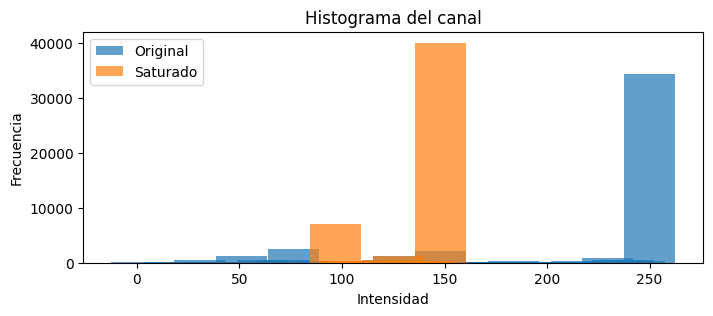

In [15]:
plt.figure(figsize=(8, 3))
plt.bar(bins_edges[:-1], h, width=25,label='Original', alpha=0.7)
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.bar(bins_edges_sat[:-1], h_sat, width=25,label='Saturado', alpha=0.7)
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma del canal')
plt.legend()

In [22]:
Irgb.shape

(251, 201, 3)

In [23]:
np.ndim(Irgb)

3

In [29]:
def HistogramaPorCanal(I=None, bins=10):
    ndim = np.ndim(I)
    if ndim == 2:
        h, bins_edges = np.histogram(I.flatten(), bins=bins, range=(0, 255))
        return h, bins_edges
    elif ndim == 3:
        _, _, nch = I.shape
        h_bins_edges_list = []
        for c in range(nch):
            h, bins_edges = np.histogram(I[:, :, c].flatten(), bins=bins, range=(0, 255))
            h_bins_edges_list.append((h, bins_edges))
        return h_bins_edges_list
    else:
        print("No está definida para este número de dimensiones")
        return None, None

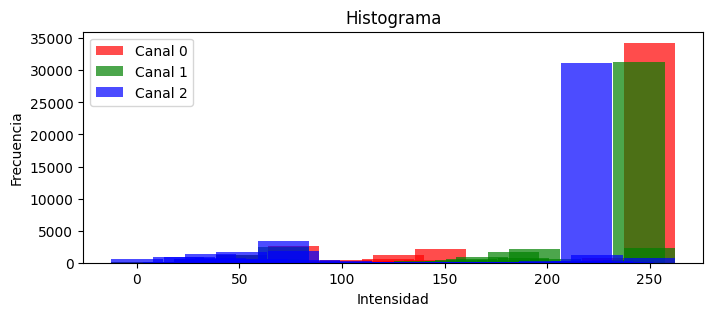

In [33]:
Img = Irgb.copy()
ndim = np.ndim(Img)
plt.figure(figsize=(8, 3))
if ndim == 2:
    h, bins_edges = HistogramaPorCanal(Img, bins=50)
    plt.bar(bins_edges[:-1], h, width=25, color='red', alpha=0.7)
elif ndim == 3:
    h_bins_edges_list = HistogramaPorCanal(Img, bins=50)
    colors = ['red', 'green', 'blue']
    for c, (h, bins_edges) in enumerate(h_bins_edges_list):
        plt.bar(bins_edges[:-1], h, width=25, color=colors[c], alpha=0.7, label=f'Canal {c}')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma')
plt.legend()

In [42]:
Img.shape

(251, 201, 3)

In [52]:
a=Img[100,50,2]
b=np.clip(a-50,0,255).astype(np.uint8)
b.dtype

dtype('uint8')

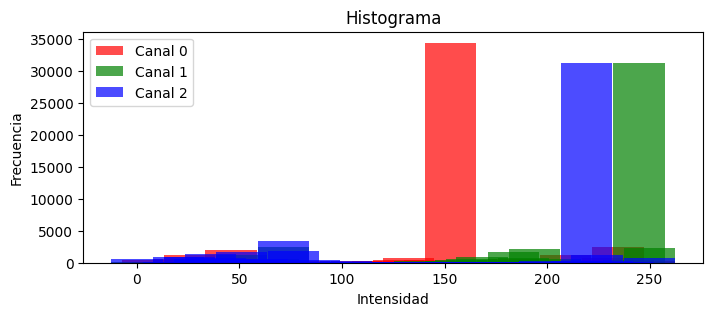

In [55]:
Irgb2 = Irgb.copy()
Ir2 = Irgb2[:, :, 0]
Ir2 = np.clip(Ir2-100,0,255).astype(np.uint8)
Irgb2[:, :, 0] = Ir2

Img = Irgb2.copy()
ndim = np.ndim(Img)
plt.figure(figsize=(8, 3))
if ndim == 2:
    h, bins_edges = HistogramaPorCanal(Img, bins=50)
    plt.bar(bins_edges[:-1], h, width=25, color='red', alpha=0.7)
elif ndim == 3:
    h_bins_edges_list = HistogramaPorCanal(Img, bins=50)
    colors = ['red', 'green', 'blue']
    for c, (h, bins_edges) in enumerate(h_bins_edges_list):
        plt.bar(bins_edges[:-1], h, width=25, color=colors[c], alpha=0.7, label=f'Canal {c}')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma')
plt.legend()



Text(0.5, 1.0, 'Modificada')

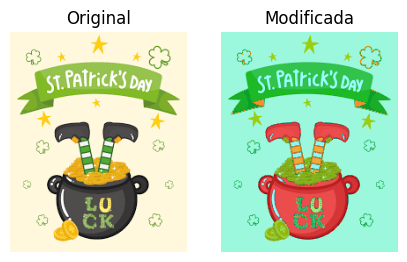

In [56]:
plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
plt.imshow(Irgb, vmin=0, vmax=255)
plt.axis('off')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(Irgb2, vmin=0, vmax=255)
plt.axis('off')
plt.title('Modificada')


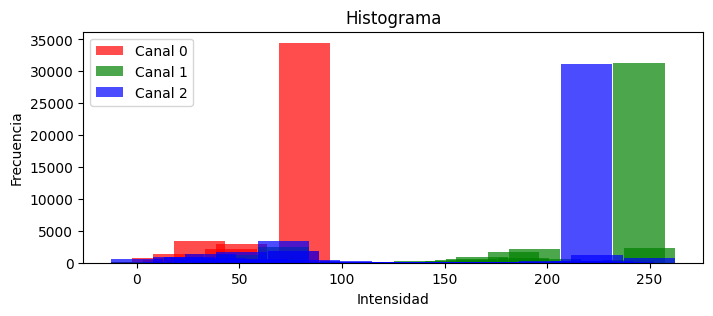

In [59]:
gamma = 0.8
Irgb3 = Irgb.copy()
Ir3 = Irgb3[:, :, 0]
Ir3 = np.clip(Ir3**gamma,0,255).astype(np.uint8)
Irgb3[:, :, 0] = Ir3

Img = Irgb3.copy()
ndim = np.ndim(Img)
plt.figure(figsize=(8, 3))
if ndim == 2:
    h, bins_edges = HistogramaPorCanal(Img, bins=50)
    plt.bar(bins_edges[:-1], h, width=25, color='red', alpha=0.7)
elif ndim == 3:
    h_bins_edges_list = HistogramaPorCanal(Img, bins=50)
    colors = ['red', 'green', 'blue']
    for c, (h, bins_edges) in enumerate(h_bins_edges_list):
        plt.bar(bins_edges[:-1], h, width=25, color=colors[c], alpha=0.7, label=f'Canal {c}')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma')
plt.legend()

Text(0.5, 1.0, 'Modificada con gamma')

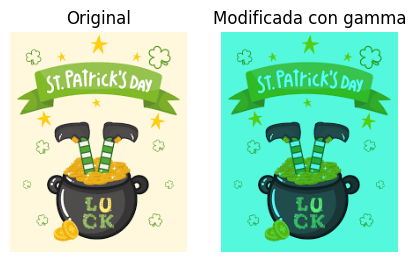

In [60]:
plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
plt.imshow(Irgb, vmin=0, vmax=255)
plt.axis('off')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(Irgb3, vmin=0, vmax=255)
plt.axis('off')
plt.title('Modificada con gamma')
